In [1]:
from google.colab import userdata

token = userdata.get("GITHUB_TOKEN")

print("Token loaded:", token is not None)

Token loaded: True


In [2]:
import os

os.environ["GITHUB_TOKEN"] = token

!git clone https://$GITHUB_TOKEN@github.com/nehnamehranmk638-dev/multilingual-rag-research.git


Cloning into 'multilingual-rag-research'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 82 (delta 36), reused 49 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 354.32 KiB | 5.91 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [3]:
%cd /content/multilingual-rag-research


/content/multilingual-rag-research


In [4]:
!git config --global credential.helper store


In [5]:
import subprocess

username = "nehnamehrankmk638-dev"

credential = f"""protocol=https
host=github.com
username={username}
password={token}

"""

subprocess.run(
    ["git", "credential", "approve"],
    input=credential,
    text=True,
    check=True
)

print("GitHub authentication configured.")


GitHub authentication configured.


In [6]:
!git fetch origin
!git switch nehna


branch 'nehna' set up to track 'origin/nehna'.
Switched to a new branch 'nehna'


In [11]:
%cd /content/multilingual-rag-research

/content/multilingual-rag-research


In [12]:
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [13]:
import os

files_to_check = [
    "results/bm25_experiments.csv",
    "results/dense_experiments.csv",
    "results/retrieval_comparison.csv",
    "results/predictions_hybrid.json",
    "results/faithfulness_labels.json"
]

for file in files_to_check:
    print(file, "->", os.path.exists(file))

results/bm25_experiments.csv -> True
results/dense_experiments.csv -> True
results/retrieval_comparison.csv -> True
results/predictions_hybrid.json -> True
results/faithfulness_labels.json -> True


In [14]:
bm25_df = pd.read_csv("results/bm25_experiments.csv")
dense_df = pd.read_csv("results/dense_experiments.csv")
retrieval_df = pd.read_csv("results/retrieval_comparison.csv")

print("BM25:")
display(bm25_df)

print("Dense:")
display(dense_df)

print("Retrieval comparison:")
display(retrieval_df)

BM25:


,run_name,k1,b,stopwords_removed,recall@1,recall@3,recall@5,recall@10,mrr


Dense:


,run_name,model_name,recall@1,recall@3,recall@5,recall@10,mrr
0,dense_baseline,intfloat/multilingual-e5-base,0.76,0.95,0.95,0.97,0.846111


Retrieval comparison:


,k,bm25_recall,dense_recall,hybrid_recall
0,1,0.79,0.76,0.84
1,3,0.88,0.95,0.93
2,5,0.91,0.95,0.95
3,10,0.95,0.97,0.97


In [15]:
with open("data/questions.json", encoding="utf-8") as f:
    questions = json.load(f)

with open("results/bm25_top10.json", encoding="utf-8") as f:
    bm25_results = json.load(f)

with open("results/dense_top10.json", encoding="utf-8") as f:
    dense_results = json.load(f)

with open("results/hybrid_top10.json", encoding="utf-8") as f:
    hybrid_results = json.load(f)

print("Questions:", len(questions))
print("BM25 results:", len(bm25_results))
print("Dense results:", len(dense_results))
print("Hybrid results:", len(hybrid_results))

Questions: 100
BM25 results: 100
Dense results: 100
Hybrid results: 100


In [16]:
def calculate_mrr(questions, results):
    total = 0.0

    for q in questions:
        qid = q["question_id"]
        retrieved = results[qid]

        if q["gold_passage_id"] in retrieved:
            rank = retrieved.index(q["gold_passage_id"]) + 1
            total += 1.0 / rank

    return total / len(questions)

In [17]:
bm25_mrr = calculate_mrr(questions, bm25_results)
dense_mrr = calculate_mrr(questions, dense_results)
hybrid_mrr = calculate_mrr(questions, hybrid_results)

print("BM25 MRR   :", round(bm25_mrr, 6))
print("Dense MRR  :", round(dense_mrr, 6))
print("Hybrid MRR :", round(hybrid_mrr, 6))

BM25 MRR   : 0.845968
Dense MRR  : 0.846111
Hybrid MRR : 0.89194


In [18]:
generation_df = pd.read_csv("results/generation_experiments.csv")

display(generation_df)

,run_name,retrieval_method,model_name,em,f1,contains_match,refusals
0,hybrid_generation,hybrid,Qwen/Qwen2.5-1.5B-Instruct,0.61,0.712394,0.76,0


In [19]:
with open("results/faithfulness_labels.json", encoding="utf-8") as f:
    labels = json.load(f)

print("Number of manually labeled cases:", len(labels))

Number of manually labeled cases: 30


In [20]:
faithfulness_counts = Counter(
    x["faithfulness"] for x in labels
)

print("Faithfulness counts:")
for label, count in faithfulness_counts.items():
    print(label, ":", count)

Faithfulness counts:
not_supported : 12
supported : 17
partial : 1


In [21]:
total = len(labels)

faithfulness_percentages = {
    label: round((count / total) * 100, 1)
    for label, count in faithfulness_counts.items()
}

print("Faithfulness percentages:")
for label, percentage in faithfulness_percentages.items():
    print(label, ":", percentage, "%")

Faithfulness percentages:
not_supported : 40.0 %
supported : 56.7 %
partial : 3.3 %


In [22]:
error_counts = Counter(
    x["error_type"]
    for x in labels
    if x["error_type"] is not None
)

print("Error types:")

for error, count in error_counts.items():
    print(error, ":", count)

Error types:
retrieval_missed : 10
generator_ignored_context : 2
none : 1


In [23]:
master_rows = [
    # Retrieval — Recall@5
    {
        "stage": "Retrieval",
        "method": "BM25",
        "metric": "Recall@5",
        "value": 0.91
    },
    {
        "stage": "Retrieval",
        "method": "Dense (E5)",
        "metric": "Recall@5",
        "value": 0.95
    },
    {
        "stage": "Retrieval",
        "method": "Hybrid (RRF)",
        "metric": "Recall@5",
        "value": 0.95
    },

    # Retrieval — MRR
    {
        "stage": "Retrieval",
        "method": "BM25",
        "metric": "MRR",
        "value": round(bm25_mrr, 6)
    },
    {
        "stage": "Retrieval",
        "method": "Dense (E5)",
        "metric": "MRR",
        "value": round(dense_mrr, 6)
    },
    {
        "stage": "Retrieval",
        "method": "Hybrid (RRF)",
        "metric": "MRR",
        "value": round(hybrid_mrr, 6)
    },

    # Generation
    {
        "stage": "Generation",
        "method": "Hybrid retrieval",
        "metric": "EM",
        "value": 0.61
    },
    {
        "stage": "Generation",
        "method": "Hybrid retrieval",
        "metric": "F1",
        "value": 0.7124
    },
    {
        "stage": "Generation",
        "method": "Hybrid retrieval",
        "metric": "Contains-match",
        "value": 0.76
    },
    {
        "stage": "Generation",
        "method": "Gold passage (ceiling)",
        "metric": "EM",
        "value": 0.70
    },
    {
        "stage": "Generation",
        "method": "Gold passage (ceiling)",
        "metric": "F1",
        "value": 0.8017
    },

    # Faithfulness
    {
        "stage": "Faithfulness",
        "method": "Manual (30 sampled)",
        "metric": "% Supported",
        "value": 56.7
    },
    {
        "stage": "Faithfulness",
        "method": "Manual (30 sampled)",
        "metric": "% Not supported",
        "value": 40.0
    },
    {
        "stage": "Faithfulness",
        "method": "Manual (30 sampled)",
        "metric": "% Partial",
        "value": 3.3
    },
    {
        "stage": "Faithfulness",
        "method": "Manual (30 sampled)",
        "metric": "% Refused",
        "value": 0.0
    }
]

master_df = pd.DataFrame(master_rows)

display(master_df)

,stage,method,metric,value
0,Retrieval,BM25,Recall@5,0.910000
1,Retrieval,Dense (E5),Recall@5,0.950000
2,Retrieval,Hybrid (RRF),Recall@5,0.950000
3,Retrieval,BM25,MRR,0.845968
4,Retrieval,Dense (E5),MRR,0.846111
5,Retrieval,Hybrid (RRF),MRR,0.891940
6,Generation,Hybrid retrieval,EM,0.610000
7,Generation,Hybrid retrieval,F1,0.712400
8,Generation,Hybrid retrieval,Contains-match,0.760000
9,Generation,Gold passage (ceiling),EM,0.700000


In [24]:
master_df.to_csv(
    "results/master_summary.csv",
    index=False
)

print("Saved: results/master_summary.csv")

Saved: results/master_summary.csv


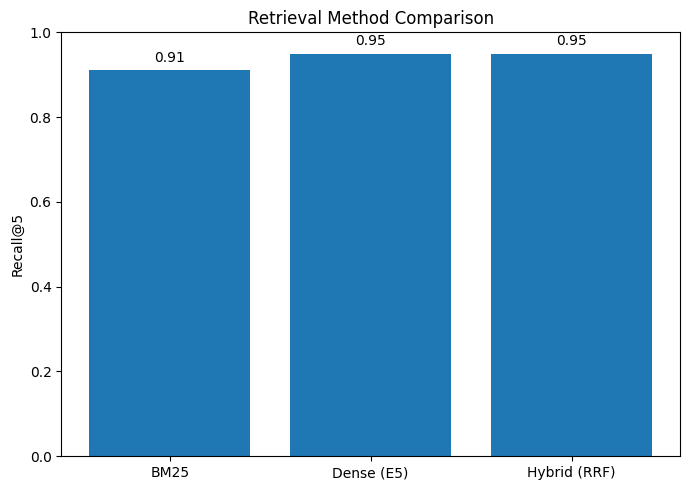

In [25]:
methods = ["BM25", "Dense (E5)", "Hybrid (RRF)"]
recall_at_5 = [0.91, 0.95, 0.95]

plt.figure(figsize=(7, 5))

plt.bar(methods, recall_at_5)

plt.ylabel("Recall@5")
plt.title("Retrieval Method Comparison")
plt.ylim(0, 1)

for i, value in enumerate(recall_at_5):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.tight_layout()

plt.savefig(
    "results/retrieval_comparison_chart.png",
    dpi=300
)

plt.show()

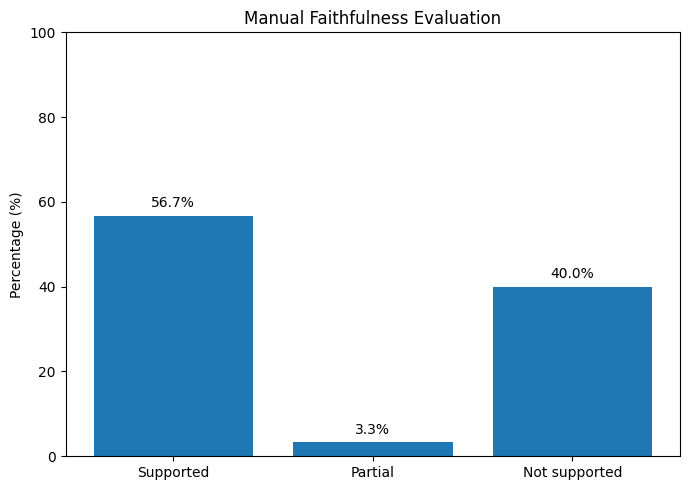

In [26]:
labels_plot = ["Supported", "Partial", "Not supported"]
values_plot = [56.7, 3.3, 40.0]

plt.figure(figsize=(7, 5))

plt.bar(labels_plot, values_plot)

plt.ylabel("Percentage (%)")
plt.title("Manual Faithfulness Evaluation")
plt.ylim(0, 100)

for i, value in enumerate(values_plot):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.tight_layout()

plt.savefig(
    "results/faithfulness_chart.png",
    dpi=300
)

plt.show()

In [27]:
em_gap = 0.70 - 0.61
f1_gap = 0.8017 - 0.7124

print("EM gap :", round(em_gap, 4))
print("F1 gap :", round(f1_gap, 4))

print("EM gap in percentage points:", round(em_gap * 100, 1))
print("F1 gap in percentage points:", round(f1_gap * 100, 1))

EM gap : 0.09
F1 gap : 0.0893
EM gap in percentage points: 9.0
F1 gap in percentage points: 8.9


In [28]:
summary_text = """
# Step 8 — Experiment Summary

## 1. Retrieval comparison

We evaluated BM25, multilingual dense retrieval using multilingual-e5-base, and hybrid retrieval using Reciprocal Rank Fusion (RRF).

At Recall@5:
- BM25: 0.91
- Dense (E5): 0.95
- Hybrid (RRF): 0.95

The hybrid method achieved 0.95 Recall@5 on our 100-question evaluation set.

## 2. Generation and gold-passage ceiling

Using hybrid retrieval, the generation results were:
- EM: 0.61
- F1: 0.7124
- Contains-match: 0.76

When the gold passage was supplied directly:
- EM: 0.70
- F1: 0.8017

The difference between hybrid retrieval and gold-passage retrieval was 9.0 percentage points for EM and 8.9 percentage points for F1 in this experiment. This indicates that retrieval quality contributes to the observed generation performance gap, although the gap should not be interpreted as an exact decomposition of all generation errors.

## 3. Manual faithfulness evaluation

We manually evaluated 30 sampled cases:
- Supported: 56.7%
- Partial: 3.3%
- Not supported: 40.0%
- Refused: 0%

The main error type was retrieval_missed:
- retrieval_missed: 10 cases
- generator_ignored_context: 2 cases

Thus, among the sampled unsupported cases, retrieval misses were more frequent than cases where the generator ignored relevant retrieved context.

## 4. Implications for multilingual evaluation

These experiments were conducted on the English evaluation setup. The retrieval and faithfulness results provide a baseline for the later multilingual phase.

The manual evaluation shows that retrieval failures are an important issue to investigate. This motivates examining retrieval quality for Malayalam, Tamil, Telugu and other target languages in the next phase, rather than assuming that English retrieval performance will transfer directly.
"""

with open("notes/summary.md", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved: notes/summary.md")

Saved: notes/summary.md


In [29]:
files_created = [
    "results/master_summary.csv",
    "results/retrieval_comparison_chart.png",
    "results/faithfulness_chart.png",
    "notes/summary.md"
]

for file in files_created:
    print(file, "->", os.path.exists(file))

results/master_summary.csv -> True
results/retrieval_comparison_chart.png -> True
results/faithfulness_chart.png -> True
notes/summary.md -> True


In [30]:
!git status

On branch nehna
Your branch is up to date with 'origin/nehna'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notes/summary.md
	results/faithfulness_chart.png
	results/master_summary.csv
	results/retrieval_comparison_chart.png

nothing added to commit but untracked files present (use "git add" to track)
